In [1]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.values
y = y.astype(int).values

In [2]:
print(X.shape)

(70000, 784)


In [3]:
print(y.shape)

(70000,)


In [4]:
X = ((X / 255.) - .5) * 2

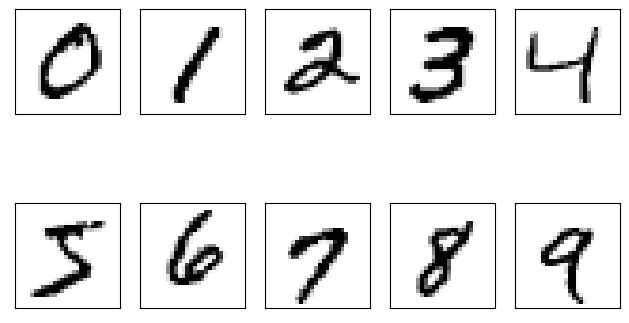

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y==i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

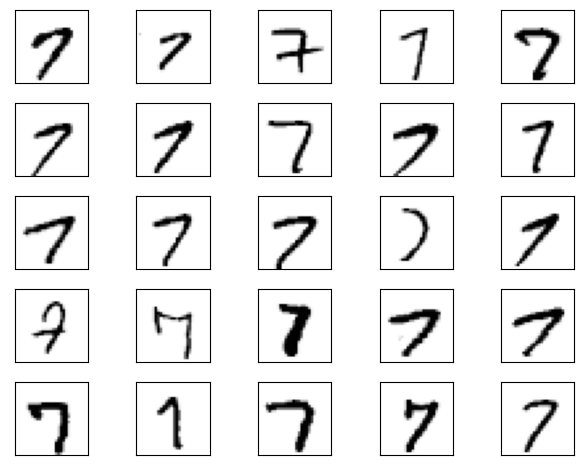

In [6]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 7][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=10000, random_state=123, stratify=y)

In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=5000, random_state=123, stratify=y_temp)

In [9]:
y_temp.shape

(60000,)

In [10]:
from neuralnet import NeuralNetMLP

In [11]:
model = NeuralNetMLP(num_features=28*28, num_hidden=50, num_classes=10)

In [12]:
import numpy as np

num_epochs = 50
minibatch_size = 100

def minibatch_generator(X, y, minibatch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    for start_idx in range(0, indices.shape[0] - minibatch_size + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]
        yield X[batch_idx], y[batch_idx]

In [13]:
# iterate over training epochs
for i in range(num_epochs):
    # iterate over minibatches
    minibatch_gen = minibatch_generator(
        X_train, y_train, minibatch_size
    )
    for X_train_mini, y_train_mini in minibatch_gen:
        break
    break

print(X_train_mini.shape)

(100, 784)


In [14]:
print(y_train_mini.shape)

(100,)


In [17]:
from neuralnet import int_to_onehot

def mse_loss(targets, probas, num_labels=10):
    onehot_targets = int_to_onehot(
        targets, num_labels=num_labels
    )
    return np.mean((onehot_targets - probas)**2)

def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets)

In [18]:
_, probas = model.forward(X_valid)
mse = mse_loss(y_valid, probas)
print(f'Initial validation MSE: {mse:.1f}')

Initial validation MSE: 0.3


In [19]:
predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_valid, predicted_labels)
print(f'Initial validation accuracy: {acc*100:.1f}%')

Initial validation accuracy: 9.4%


In [20]:
def compute_mse_and_acc(nnet, X, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(X, y, minibatch_size)
    for i, (features, targets) in enumerate(minibatch_gen):
        _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)
        onehot_targets = int_to_onehot(
            targets, num_labels=num_labels
        )
        loss = np.mean((onehot_targets - probas) ** 2)
        correct_pred += (predicted_labels == targets).sum()
        num_examples += targets.shape[0]
        mse += loss
    
    mse = mse / i
    acc = correct_pred / num_examples
    return mse, acc

In [21]:
mse, acc = compute_mse_and_acc(model, X_valid, y_valid)
print(f'Initial valid MSE: {mse:.1f}')

Initial valid MSE: 0.3


In [23]:
print(f'Initial valid accuracy: {acc*100:.1f}%')

Initial valid accuracy: 9.4%


In [25]:
def train(model, X_train, y_train, X_valid, y_valid, num_epochs, learning_rate=0.1):
    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []

    for e in range(num_epochs):
        # Iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size
        )
        for X_train_mini, y_train_mini in minibatch_gen:
            #### Compute output ####
            a_h, a_out = model.forward(X_train_mini)
            #### Compute gradient ####
            d_loss__d_w_out, d_loss__d_b_out, d_loss__d_w_h, d_loss__d_b_h = model.backward(X_train_mini, a_h, a_out, y_train_mini)

            #### Update weights ####
            model.weight_h -= learning_rate * d_loss__d_w_h
            model.bias_h -= learning_rate * d_loss__d_b_h
            model.weight_out -= learning_rate * d_loss__d_w_out
            model.bias_out -= learning_rate * d_loss__d_b_out
        
        #### Epoch logging #####
        train_mse, train_acc = compute_mse_and_acc(
            model, X_train, y_train
        )
        valid_mse, valid_acc = compute_mse_and_acc(
            model, X_valid, y_valid
        )
        train_acc, valid_acc = train_acc*100, valid_acc*100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} | Train MSE: {train_mse:.2f} | Train Acc: {train_acc:.2f} | Valid Acc: {valid_acc:.2f}')
    
    return epoch_loss, epoch_train_acc, epoch_valid_acc

In [26]:
np.random.seed(123)
epoch_loss, epoch_train_acc, epoch_valid_acc = train(model, X_train, y_train, X_valid, y_valid, num_epochs=50, learning_rate=0.1)

Epoch: 001/050 | Train MSE: 0.05 | Train Acc: 76.15 | Valid Acc: 75.98
Epoch: 002/050 | Train MSE: 0.03 | Train Acc: 85.45 | Valid Acc: 85.04
Epoch: 003/050 | Train MSE: 0.02 | Train Acc: 87.82 | Valid Acc: 87.60
Epoch: 004/050 | Train MSE: 0.02 | Train Acc: 89.36 | Valid Acc: 89.28
Epoch: 005/050 | Train MSE: 0.02 | Train Acc: 90.21 | Valid Acc: 90.04
Epoch: 006/050 | Train MSE: 0.02 | Train Acc: 90.67 | Valid Acc: 90.54
Epoch: 007/050 | Train MSE: 0.02 | Train Acc: 91.12 | Valid Acc: 90.82
Epoch: 008/050 | Train MSE: 0.02 | Train Acc: 91.43 | Valid Acc: 91.26
Epoch: 009/050 | Train MSE: 0.01 | Train Acc: 91.84 | Valid Acc: 91.50
Epoch: 010/050 | Train MSE: 0.01 | Train Acc: 92.04 | Valid Acc: 91.84
Epoch: 011/050 | Train MSE: 0.01 | Train Acc: 92.30 | Valid Acc: 92.08
Epoch: 012/050 | Train MSE: 0.01 | Train Acc: 92.51 | Valid Acc: 92.24
Epoch: 013/050 | Train MSE: 0.01 | Train Acc: 92.65 | Valid Acc: 92.30
Epoch: 014/050 | Train MSE: 0.01 | Train Acc: 92.80 | Valid Acc: 92.60
Epoch:

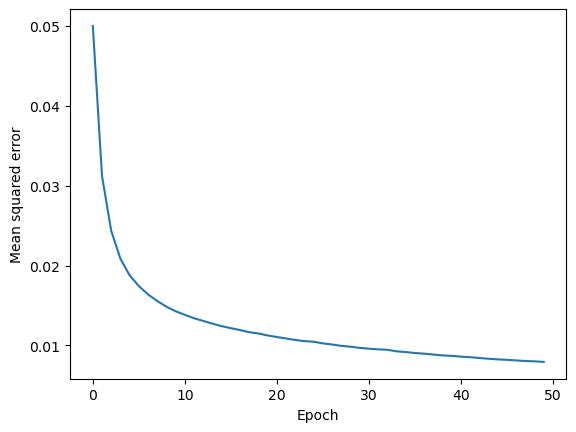

In [27]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel('Mean squared error')
plt.xlabel('Epoch')
plt.show()

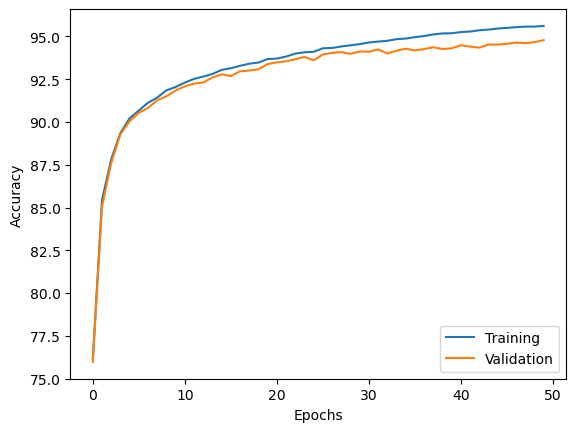

In [28]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc, label='Training')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc, label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
plt.show()

In [29]:
test_mse, test_acc = compute_mse_and_acc(model, X_test, y_test)
print(f'Test accuracy: {test_acc*100:.2f}%')

Test accuracy: 94.54%


In [33]:
X_test_subset = X_test[:1000, :]
y_test_subset = y_test[:1000]
_, probas = model.forward(X_test_subset)
test_pred = np.argmax(probas, axis=1)
misclassified_imges = X_test_subset[y_test_subset != test_pred][:25]
misclassified_labels = test_pred[y_test_subset != test_pred][:25]
correct_labels = y_test_subset[y_test_subset != test_pred][:25]

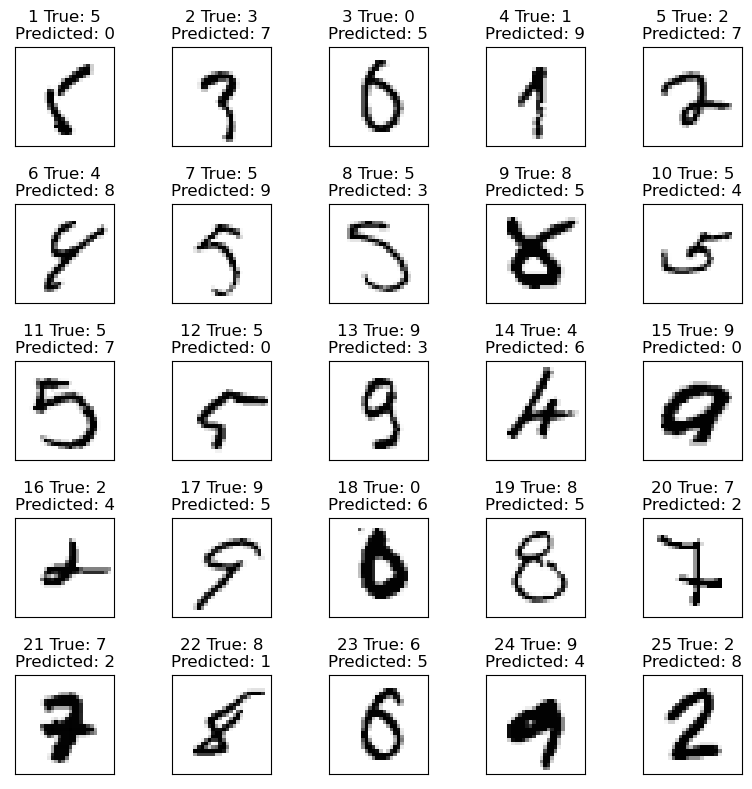

In [34]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True, figsize=(8, 8))
ax = ax.flatten()
for i in range(25):
    img = misclassified_images[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')
    ax[i].set_title(f'{i+1} True: {correct_labels[i]}\nPredicted: {misclassified_labels[i]}')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()